<a href="https://colab.research.google.com/github/mugalan/introduction-to-statistical-learning/blob/main/assignments/fundamentals_of_probability_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


Model 1: Uniformly distributed with respect to area

Total Area:
$A_{total} = \pi r^2 = \pi (10)^2 = 100\pi$.

Event $A$: The point lies within 1 unit of the boundary (the "outer ring").

This area is the total area minus the area of the inner circle with radius $r=9$.

Area of $A$: $100\pi - \pi(9)^2 = 100\pi - 81\pi = 19\pi$.

$P(A) = \frac{19\pi}{100\pi} = \mathbf{0.19}$.

Model 2: Uniform distance and directionDistance ($R$): Chosen uniformly from $[0, 10]$.

Event $A$: The point lies within 1 unit of the boundary, meaning $9 \leq R \leq 10$.

$P(A) = \frac{10 - 9}{10 - 0} = \frac{1}{10} = \mathbf{0.10}$.

Why they differIn the first model,

The probability is proportional to the area, which grows quadratically with the radius. In the second model, the probability is proportional to the linear distance, treating every interval of the radius as equally likely regardless of how much area it represents.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

R = 10  # radius of disk

# ── Part 1: Uniform w.r.t. Area ──────────────────────────────────────────────
# A = {point lies within 1 unit of boundary} = annulus [9, 10]
# Area of disk = π R²   Area of inner disk (r ≤ 9) = π·9²
P_A_area = (np.pi * R**2 - np.pi * 9**2) / (np.pi * R**2)
print(f"Part 1 – Uniform w.r.t. Area:")
print(f"  P(A) = (π·10² - π·9²) / π·10²  =  (100 - 81)/100  =  19/100  = {P_A_area:.4f}")

# ── Part 2: Uniform distance from center ─────────────────────────────────────
# r ~ Uniform[0, 10], independent θ ~ Uniform[0, 2π)
# A = {r ≥ 9}
# P(A) = P(r ∈ [9,10]) = (10 - 9)/(10 - 0)
P_A_dist = (10 - 9) / (10 - 0)
print(f"\nPart 2 – Uniform Distance:")
print(f"  P(A) = (10 - 9) / 10  =  1/10  = {P_A_dist:.4f}")

# ── Part 3: Explanation ───────────────────────────────────────────────────────
print("""
Part 3 – Why the answers differ:
  The two models assign probability in fundamentally different ways.

  Model 1 (uniform in area): equal probability to equal *areas*.
    Points near the boundary cover a large area (the wide annulus), so
    the boundary region gets high probability ≈ 19%.

  Model 2 (uniform in radial distance): equal probability to equal
    *radial intervals*.  The interval [9,10] is only 1/10 of [0,10],
    so P(A) = 10%, regardless of how much area that annulus covers.

  "Uniform" is not absolute—it depends on the measure (area vs. length
  of radius).  The two models induce different probability measures on
  the same sample space, so they give different numbers.
""")

# ── Verification by Monte-Carlo ───────────────────────────────────────────────
np.random.seed(42)
N = 1_000_000

# Model 1: rejection sampling inside disk
pts = []
while len(pts) < N:
    x, y = np.random.uniform(-R, R, 2)
    if x**2 + y**2 <= R**2:
        pts.append((x, y))
pts = np.array(pts)
r_area = np.sqrt(pts[:,0]**2 + pts[:,1]**2)
mc1 = np.mean(r_area >= 9)

# Model 2: r uniform, θ uniform
r_dist = np.random.uniform(0, R, N)
mc2 = np.mean(r_dist >= 9)

print(f"Monte-Carlo verification (N={N:,}):")
print(f"  Model 1 P(A) ≈ {mc1:.4f}  (exact {P_A_area:.4f})")
print(f"  Model 2 P(A) ≈ {mc2:.4f}  (exact {P_A_dist:.4f})")


Part 1 – Uniform w.r.t. Area:
  P(A) = (π·10² - π·9²) / π·10²  =  (100 - 81)/100  =  19/100  = 0.1900

Part 2 – Uniform Distance:
  P(A) = (10 - 9) / 10  =  1/10  = 0.1000

Part 3 – Why the answers differ:
  The two models assign probability in fundamentally different ways.

  Model 1 (uniform in area): equal probability to equal *areas*.
    Points near the boundary cover a large area (the wide annulus), so
    the boundary region gets high probability ≈ 19%.

  Model 2 (uniform in radial distance): equal probability to equal
    *radial intervals*.  The interval [9,10] is only 1/10 of [0,10],
    so P(A) = 10%, regardless of how much area that annulus covers.

  "Uniform" is not absolute—it depends on the measure (area vs. length
  of radius).  The two models induce different probability measures on
  the same sample space, so they give different numbers.

Monte-Carlo verification (N=1,000,000):
  Model 1 P(A) ≈ 0.1898  (exact 0.1900)
  Model 2 P(A) ≈ 0.1001  (exact 0.1000)


# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

Bertrand's Paradox demonstrates that "at random" is ill-defined for continuous spaces. The side length of an inscribed equilateral triangle in a circle of radius $R$ is $L = R\sqrt{3}$.

Random Endpoints Method: Fix one point and pick another.

The chord exceeds $L$ if the second point is within a $120^\circ$ arc.

$P = 1/3$

Random Radial Distance Method: Choose a radius and a point on it.

The chord exceeds $L$ if the point is closer to the center than $R/2$

$P = 1/2$

Random Midpoint Method: Choose a point anywhere in the circle as the chord's midpoint. The chord exceeds $L$ if the point falls within an inner circle of radius $R/2$.$P = \text{Area Ratio} = \frac{\pi(R/2)^2}{\pi R^2} = 1/4$

Method 1 (random endpoints):  P = 2/3 ≈ 0.6667
  Monte-Carlo ≈ 0.3329

Method 2 (random midpoint):  P = 1/4 = 0.2500
  Monte-Carlo ≈ 0.2495

Method 3 (random radius):  P = 1/2 = 0.5000
  Monte-Carlo ≈ 0.5001

Explanation of Bertrand's Paradox:
  The three methods each define a mathematically natural probability
  measure on the space of chords, but they are *different* measures.
  The phrase "chosen at random" is ambiguous unless the underlying
  probability space is specified.  This illustrates that probability
  is not determined by geometry alone—the choice of sample space and
  measure matters.



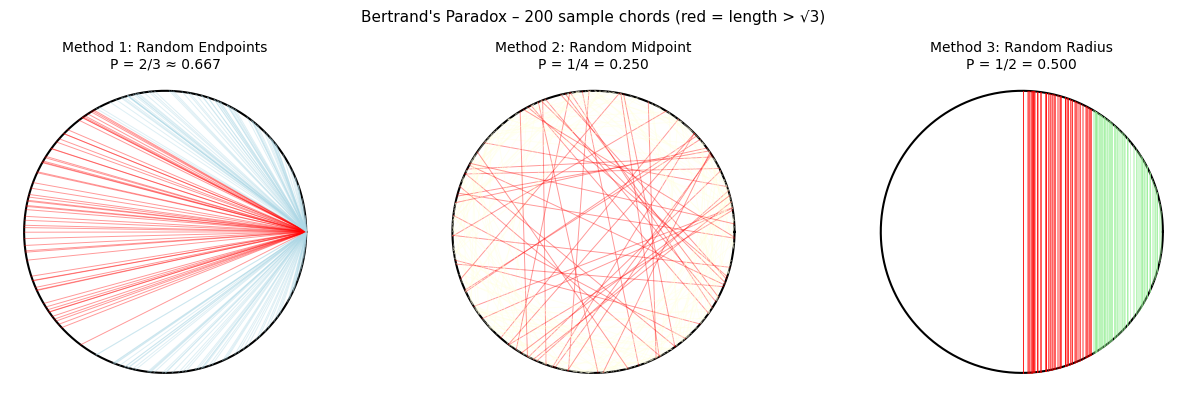

Plot saved as bertrand_paradox.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Background ───────────────────────────────────────────────────────────────
# Circle of radius 1.  Inscribed equilateral triangle side = √3.
# A chord is longer than √3  ⟺  its length > √3.
# Three classical "uniform" models give three different answers.

R = 1.0
side_len = np.sqrt(3)          # side of inscribed equilateral triangle

# ═══════════════════════════════════════════════════════════════════════════
# METHOD 1 – Random Endpoints  (uniform endpoint pair on the circle)
#   Fix one endpoint at angle 0.  Second endpoint θ ~ Uniform[0, 2π).
#   Chord length = 2 sin(θ/2).  Chord > √3  ⟺  sin(θ/2) > √3/2  ⟺  θ ∈ (π/3, 5π/3).
#   P = (5π/3 - π/3) / 2π  =  4π/3 / 2π  =  2/3
P1_exact = 2/3
print(f"Method 1 (random endpoints):  P = 2/3 ≈ {P1_exact:.4f}")

np.random.seed(0)
N = 2_000_000
theta = np.random.uniform(0, 2*np.pi, N)
lengths1 = 2 * np.sin(theta / 2)
mc1 = np.mean(lengths1 > side_len)
print(f"  Monte-Carlo ≈ {mc1:.4f}")

# ═══════════════════════════════════════════════════════════════════════════
# METHOD 2 – Random Midpoint  (midpoint uniform over the disk)
#   Chord longer than √3  ⟺  midpoint within radius 1/2 of center.
#   P = π(1/2)² / π(1)²  =  1/4
P2_exact = 1/4
print(f"\nMethod 2 (random midpoint):  P = 1/4 = {P2_exact:.4f}")

x = np.random.uniform(-1, 1, N * 5)
y = np.random.uniform(-1, 1, N * 5)
mask = x**2 + y**2 <= 1
x, y = x[mask][:N], y[mask][:N]
# chord length from midpoint distance d: chord = 2√(R² - d²)
d = np.sqrt(x**2 + y**2)
lengths2 = 2 * np.sqrt(np.maximum(R**2 - d**2, 0))
mc2 = np.mean(lengths2 > side_len)
print(f"  Monte-Carlo ≈ {mc2:.4f}")

# ═══════════════════════════════════════════════════════════════════════════
# METHOD 3 – Random Radius  (midpoint on a fixed radius, uniform in [0,1])
#   Chord longer than √3  ⟺  distance to center d < 1/2.
#   P = (1/2) / 1  =  1/2
P3_exact = 1/2
print(f"\nMethod 3 (random radius):  P = 1/2 = {P3_exact:.4f}")

d3 = np.random.uniform(0, R, N)
lengths3 = 2 * np.sqrt(np.maximum(R**2 - d3**2, 0))
mc3 = np.mean(lengths3 > side_len)
print(f"  Monte-Carlo ≈ {mc3:.4f}")

# ═══════════════════════════════════════════════════════════════════════════
print("""
Explanation of Bertrand's Paradox:
  The three methods each define a mathematically natural probability
  measure on the space of chords, but they are *different* measures.
  The phrase "chosen at random" is ambiguous unless the underlying
  probability space is specified.  This illustrates that probability
  is not determined by geometry alone—the choice of sample space and
  measure matters.
""")

# ── Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles = [f'Method 1: Random Endpoints\nP = 2/3 ≈ {P1_exact:.3f}',
          f'Method 2: Random Midpoint\nP = 1/4 = {P2_exact:.3f}',
          f'Method 3: Random Radius\nP = 1/2 = {P3_exact:.3f}']
colors = ['steelblue', 'darkorange', 'seagreen']

for ax, title, col in zip(axes, titles, colors):
    theta_circ = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(theta_circ), np.sin(theta_circ), 'k', lw=1.5)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=10)
    ax.axis('off')

# Sample 200 chords for each method and colour-code
n_show = 200

# Method 1
theta2 = np.random.uniform(0, 2*np.pi, n_show)
x1a, y1a = np.cos(0), np.sin(0)
x1b, y1b = np.cos(theta2), np.sin(theta2)
lengths_show1 = 2 * np.sin(theta2 / 2)
for i in range(n_show):
    col = 'red' if lengths_show1[i] > side_len else 'lightblue'
    axes[0].plot([x1a, x1b[i]], [y1a, y1b[i]], color=col, alpha=0.4, lw=0.7)

# Method 2
xs = np.random.uniform(-1, 1, n_show * 10)
ys = np.random.uniform(-1, 1, n_show * 10)
mk = xs**2 + ys**2 <= 1
xs, ys = xs[mk][:n_show], ys[mk][:n_show]
ds = np.sqrt(xs**2 + ys**2)
for i in range(n_show):
    angle = np.arctan2(ys[i], xs[i])
    half = np.sqrt(max(1 - ds[i]**2, 0))
    perp = angle + np.pi/2
    x2a = xs[i] + half*np.cos(perp); y2a = ys[i] + half*np.sin(perp)
    x2b = xs[i] - half*np.cos(perp); y2b = ys[i] - half*np.sin(perp)
    chord_len = 2*half
    col = 'red' if chord_len > side_len else 'lightyellow'
    axes[1].plot([x2a, x2b], [y2a, y2b], color=col, alpha=0.4, lw=0.7)

# Method 3
ds3 = np.random.uniform(0, 1, n_show)
for i in range(n_show):
    half = np.sqrt(max(1 - ds3[i]**2, 0))
    col = 'red' if 2*half > side_len else 'lightgreen'
    axes[2].plot([ds3[i], ds3[i]], [-half, half], color=col, alpha=0.4, lw=0.7)

plt.suptitle("Bertrand's Paradox – 200 sample chords (red = length > √3)", fontsize=11)
plt.tight_layout()
plt.savefig('bertrand_paradox.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as bertrand_paradox.png")


#Q8) Probability of Being a Girl?

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

This is a classic conditional probability problem.

Sample Space ($\Omega$): $\{BB, BG, GB, GG\}$

(Each has probability $1/4$).

Condition ($C$): "At least one is a girl" = $\{BG, GB, GG\}$.

Event ($E$): "Both are girls" = $\{GG\}$.

$P(E|C) = \frac{P(E \cap C)}{P(C)} = \frac{1/4}{3/4} = \mathbf{1/3}$.

In [ ]:
# Q8: Probability of Both Girls Given At Least One Girl

# Sample space: ordered pairs (first child, second child)
sample_space = [('B','B'), ('B','G'), ('G','B'), ('G','G')]
print("Sample space Ω = {BB, BG, GB, GG}, each with probability 1/4")

# Event A: both girls
A = {('G','G')}
# Event B: at least one girl
B = {('B','G'), ('G','B'), ('G','G')}

P_A = len(A) / len(sample_space)
P_B = len(B) / len(sample_space)
A_and_B = A & B
P_A_and_B = len(A_and_B) / len(sample_space)

# Conditional probability P(A | B) = P(A ∩ B) / P(B)
P_A_given_B = P_A_and_B / P_B

print(f"""
P(both girls) = P(GG) = {P_A}""")
print(f"P(at least one girl) = P(BG ∪ GB ∪ GG) = {P_B}")
print(f"P(both girls AND at least one girl) = {P_A_and_B}")
print(f"""
P(both girls | at least one girl)""")
print(f"  = P(GG ∩ {{BG,GB,GG}}) / P({{BG,GB,GG}})")
print(f"  = {P_A_and_B} / {P_B}")
print(f"  = {P_A_given_B:.4f}  =  1/3")

print("""
Interpretation:
  Given that at least one child is a girl, the three equally likely outcomes
  consistent with this condition are {BG, GB, GG}.  Only one of these has
  both children as girls, so P(GG | ≥1 girl) = 1/3.

  This is different from P(second is G | first is G) = 1/2  — a common
  source of confusion.  The key is that the conditioning event "at least one
  girl" does not tell us *which* child is the girl.
""")

Sample space Ω = {BB, BG, GB, GG}, each with probability 1/4

P(both girls) = P(GG) = 0.25
P(at least one girl) = P(BG ∪ GB ∪ GG) = 0.75
P(both girls AND at least one girl) = 0.25

P(both girls | at least one girl)
  = P(GG ∩ {BG,GB,GG}) / P({BG,GB,GG})
  = 0.25 / 0.75
  = 0.3333  =  1/3

Interpretation:
  Given that at least one child is a girl, the three equally likely outcomes
  consistent with this condition are {BG, GB, GG}.  Only one of these has
  both children as girls, so P(GG | ≥1 girl) = 1/3.

  This is different from P(second is G | first is G) = 1/2  — a common
  source of confusion.  The key is that the conditioning event "at least one
  girl" does not tell us *which* child is the girl.



# Q9) Information Available in a Discrete Random Variable

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$.

1. Probability Space: $\Omega = \{G_1, G_2, D_1, D_2\}$; $\mathfrak{F} = \text{Power set of } \Omega$; $P$ as given ($0.5, 0.2, 0.1, 0.2$).

2. $\sigma(X)$: Generated by $X^{-1}(\{0\}) = \{G_1, G_2\}$ and $X^{-1}(\{1\}) = \{D_1, D_2\}$. $\sigma(X) = \{\emptyset, \Omega, \{G_1, G_2\}, \{D_1, D_2\}\}$.

3. $\sigma(Y)$: Since $Y$ gives a unique value for every element in $\Omega$, $\sigma(Y) = \mathfrak{F}$ (all possible subsets).

4. Relationship: $\sigma(X) \subseteq \sigma(Y)$ because every set in $\sigma(X)$ can be formed by unions of sets in $\sigma(Y)$. $Y$ is "finer" because it distinguishes between machines; $X$ only sees quality.

5. Marginal $X$: $P(X=0) = 0.70$, $P(X=1) = 0.30$.

6. Marginal $Y$: $P(Y=1)=0.5, P(Y=2)=0.2, P(Y=3)=0.1, P(Y=4)=0.2$.

7. Joint Probabilities: $P(X=0, Y=1) = 0.5$; $P(X=1, Y=4) = 0.2$.

8. Conditional: $P(X=1|Y=3) = \mathbf{1}$ (If you know it's $Y=3$, it's definitely defective); $P(Y=3|X=1) = \frac{0.1}{0.3} = \mathbf{1/3}$.

1. Probability space (Ω, F, P):
   Ω = {G1, G2, D1, D2}
   F = P(Ω) = power set (16 subsets)
   P({G1}) = 0.5
   P({G2}) = 0.2
   P({D1}) = 0.1
   P({D2}) = 0.2

2. σ(X):
   X takes value 0 on {G1,G2} and 1 on {D1,D2}.
   σ(X) = {∅, {G1,G2}, {D1,D2}, Ω}

3. σ(Y):
   Y is injective → σ(Y) = P(Ω) (all 16 subsets)

4. σ(X) ⊆ σ(Y): Every set in σ(X) is a union of singletons, hence in P(Ω)=σ(Y). ✓
   Y carries more information because it distinguishes *which* machine produced the item.

5. Marginal distribution of X:
   P(X=0) = P(G1)+P(G2) = 0.5+0.2 = 0.7
   P(X=1) = P(D1)+P(D2) = 0.1+0.2 = 0.30000000000000004

6. Marginal distribution of Y (each singleton):
   P(Y=1) = P({G1}) = 0.5
   P(Y=2) = P({G2}) = 0.2
   P(Y=3) = P({D1}) = 0.1
   P(Y=4) = P({D2}) = 0.2

7. Joint probabilities P(X=x, Y=y):
   P(X=0,Y=1) = P(G1) = 0.5  (G1 is good on machine 1)
   P(X=0,Y=2) = P(G2) = 0.2
   P(X=1,Y=3) = P(D1) = 0.1
   P(X=1,Y=4) = P(D2) = 0.2
   (All other joint probs = 0, since X is determined by Y

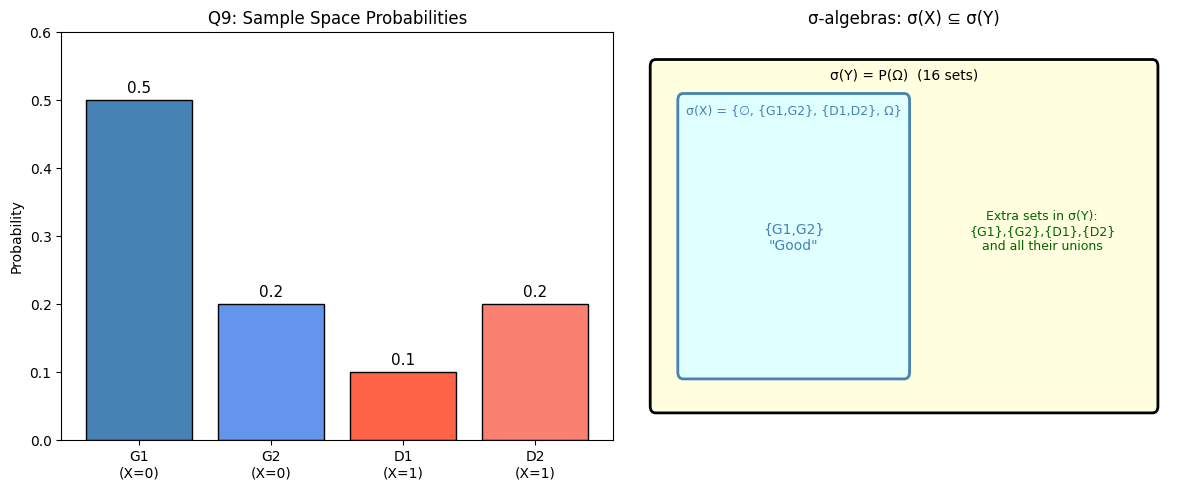

12. Shannon Entropy:
   H(X) = 0.8813 bits
   H(Y) = 1.7610 bits
   H(X,Y) = H(Y) = 1.7610 bits  (X is a function of Y)
   H(X|Y) = H(X,Y) - H(Y) = 0.0000 bits  (Y fully determines X)
   H(Y|X) = H(X,Y) - H(X) = 0.8797 bits
   Mutual info I(X;Y) = H(X) - H(X|Y) = 0.8813 bits
   (Y carries 0.8813 bits about X, but X carries only 0.8813 bits about Y)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import entropy

# ── Setup ─────────────────────────────────────────────────────────────────────
omega = ['G1', 'G2', 'D1', 'D2']
P     = {'G1': 0.50, 'G2': 0.20, 'D1': 0.10, 'D2': 0.20}

# X: quality indicator  (0=good, 1=defective)
X_map = {'G1': 0, 'G2': 0, 'D1': 1, 'D2': 1}
# Y: full label (1..4)
Y_map = {'G1': 1, 'G2': 2, 'D1': 3, 'D2': 4}

# 1. Probability space
print("1. Probability space (Ω, F, P):")
print("   Ω = {G1, G2, D1, D2}")
print("   F = P(Ω) = power set (16 subsets)")
for w in omega:
    print(f"   P({{{w}}}) = {P[w]}")

# 2. σ(X)
print("""
2. σ(X):""")
print("   X takes value 0 on {G1,G2} and 1 on {D1,D2}.")
print("   σ(X) = {∅, {G1,G2}, {D1,D2}, Ω}")

# 3. σ(Y)
print("""
3. σ(Y):""")
print("   Y is injective → σ(Y) = P(Ω) (all 16 subsets)")

# 4. σ(X) ⊆ σ(Y)
print("""
4. σ(X) ⊆ σ(Y): Every set in σ(X) is a union of singletons, hence in P(Ω)=σ(Y). ✓""")
print("   Y carries more information because it distinguishes *which* machine produced the item.")

# 5. Marginal of X
p_X0 = sum(P[w] for w in omega if X_map[w] == 0)
p_X1 = sum(P[w] for w in omega if X_map[w] == 1)
print(f"""
5. Marginal distribution of X:""")
print(f"   P(X=0) = P(G1)+P(G2) = {P['G1']}+{P['G2']} = {p_X0}")
print(f"   P(X=1) = P(D1)+P(D2) = {P['D1']}+{P['D2']} = {p_X1}")

# 6. Marginal of Y
print("""
6. Marginal distribution of Y (each singleton):""")
for w in omega:
    print(f"   P(Y={Y_map[w]}) = P({{{w}}}) = {P[w]}")

# 7. Joint probabilities
print("""
7. Joint probabilities P(X=x, Y=y):""")
print(f"   P(X=0,Y=1) = P(G1) = {P['G1']}  (G1 is good on machine 1)")
print(f"   P(X=0,Y=2) = P(G2) = {P['G2']}")
print(f"   P(X=1,Y=3) = P(D1) = {P['D1']}")
print(f"   P(X=1,Y=4) = P(D2) = {P['D2']}")
print("   (All other joint probs = 0, since X is determined by Y)")

# 8. Conditional probabilities
print("""
8. Conditional probabilities:""")
# P(X=1 | Y=3): Y=3 means D1, which has X=1 → P=1
print(f"   P(X=1|Y=3) = P(X=1,Y=3)/P(Y=3) = {P['D1']}/{P['D1']} = 1.0")
print(f"   P(X=1|Y=4) = P(X=1,Y=4)/P(Y=4) = {P['D2']}/{P['D2']} = 1.0")
# P(Y=3 | X=1)
p_Y3_given_X1 = P['D1'] / p_X1
p_Y4_given_X1 = P['D2'] / p_X1
print(f"   P(Y=3|X=1) = P(D1)/P(X=1) = {P['D1']}/{p_X1} = {p_Y3_given_X1:.4f}")
print(f"   P(Y=4|X=1) = P(D2)/P(X=1) = {P['D2']}/{p_X1} = {p_Y4_given_X1:.4f}")

# 9. Interpretation
print("""
9. Interpretation:
   - Conditioning on Y tells us *exactly* which machine produced the item,
     so X is completely determined (hence P(X|Y)=0 or 1).
   - Conditioning on X (e.g. X=1) only tells us "defective"; Y=3 or Y=4
     are still uncertain, with probabilities reflecting the relative
     frequency of defects from each machine.
""")

# 10.
print("""10. Information in σ(X) vs σ(Y):
    σ(X) contains only quality information (good/defective) — not machine.
    σ(Y) = P(Ω) contains all information, including which machine.
    σ(X) ⊂ σ(Y) strictly: σ(Y) adds knowledge of the producing machine,
    which σ(X) completely discards.
""")

# 11. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Probability bar chart
ax = axes[0]
bar_labels = ['G1\n(X=0)', 'G2\n(X=0)', 'D1\n(X=1)', 'D2\n(X=1)']
bar_probs  = [P[w] for w in omega]
colors     = ['steelblue', 'cornflowerblue', 'tomato', 'salmon']
bars = ax.bar(bar_labels, bar_probs, color=colors, edgecolor='black')
ax.set_ylabel('Probability'); ax.set_title('Q9: Sample Space Probabilities')
ax.set_ylim(0, 0.6)
for bar, val in zip(bars, bar_probs):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val}', ha='center', fontsize=11)

# σ-algebra diagram (Venn-style)
ax2 = axes[1]
ax2.set_xlim(0, 10); ax2.set_ylim(0, 6); ax2.axis('off')
ax2.set_title('σ-algebras: σ(X) ⊆ σ(Y)')
ax2.add_patch(mpatches.FancyBboxPatch((0.5, 0.5), 9, 5, boxstyle='round,pad=0.1',
              edgecolor='black', facecolor='lightyellow', lw=2))
ax2.add_patch(mpatches.FancyBboxPatch((1, 1), 4, 4, boxstyle='round,pad=0.1',
              edgecolor='steelblue', facecolor='lightcyan', lw=2))
ax2.text(5, 5.3, 'σ(Y) = P(Ω)  (16 sets)', ha='center', color='black', fontsize=10)
ax2.text(3, 4.8, 'σ(X) = {∅, {G1,G2}, {D1,D2}, Ω}', ha='center', color='steelblue', fontsize=9)
ax2.text(3, 2.8, '{G1,G2}\n"Good"', ha='center', color='steelblue', fontsize=10)
ax2.text(7.5, 2.8, 'Extra sets in σ(Y):\n{G1},{G2},{D1},{D2}\nand all their unions',
         ha='center', color='darkgreen', fontsize=9)

plt.tight_layout()
plt.savefig('q9_viz.png', dpi=100, bbox_inches='tight')
plt.show()

# 12. Shannon Entropy
print("12. Shannon Entropy:")
# Marginal H(X)
H_X = entropy([p_X0, p_X1], base=2)
# Marginal H(Y)
py_vals = [P[w] for w in omega]
H_Y = entropy(py_vals, base=2)
# Joint H(X,Y) = H(Y) since (X,Y) uniquely determined by Y
H_XY = H_Y
# Conditional H(X|Y) = H(X,Y) - H(Y) = 0 (X is function of Y)
H_X_given_Y = H_XY - H_Y
# Conditional H(Y|X)
H_Y_given_X = H_XY - H_X

print(f"   H(X) = {H_X:.4f} bits")
print(f"   H(Y) = {H_Y:.4f} bits")
print(f"   H(X,Y) = H(Y) = {H_XY:.4f} bits  (X is a function of Y)")
print(f"   H(X|Y) = H(X,Y) - H(Y) = {H_X_given_Y:.4f} bits  (Y fully determines X)")
print(f"   H(Y|X) = H(X,Y) - H(X) = {H_Y_given_X:.4f} bits")
print(f"   Mutual info I(X;Y) = H(X) - H(X|Y) = {H_X - H_X_given_Y:.4f} bits")
print(f"   (Y carries {H_X:.4f} bits about X, but X carries only {H_Y - H_Y_given_X:.4f} bits about Y)")


# Q10) Information Available in Continuous Random Varaibles

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

13. Compute the differential entropy of $X$:

$$
h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx.
$$

14. Compute the differential entropy of $Y$:

$$
h(Y)=-\int_{\mathbb R^2} f_Y(t,p)\ln f_Y(t,p)\,dt\,dp.
$$

15. Compute the conditional differential entropy

$$
h(Y|X),
$$

and interpret it physically.

16. Discuss what happens to

$$
h(X|Y)
$$

in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other.


Core Concepts:

$X$ vs $Y$: $X$ is just the temperature ($T$), while $Y$ is the pair $(T, P)$.

Measurability: $X$ is a "coarser" observation. Knowing $Y$ means you automatically know $X$, but knowing $X$ leaves $P$ unknown.

Marginal $X$: $X \sim N(0, 1)$.

Entropy:

$h(X) = \frac{1}{2}\ln(2\pi e \sigma^2) = \frac{1}{2}\ln(2\pi e)$ since $\sigma^2=1$.

$h(Y) = h(T) + h(P)$ (due to independence) $= \frac{1}{2}\ln(2\pi e(1)) + \frac{1}{2}\ln(2\pi e(4))$.

Conditional Entropy

$h(Y|X)$: This equals $h(P) = \frac{1}{2}\ln(8\pi e)$. This represents the "remaining uncertainty" about the pressure once the temperature is known.

$h(X|Y)$: Since $X$ is a deterministic function of $Y$, the uncertainty is zero ($-\infty$ in differential entropy terms, though interpreted carefully in the limit).

1. Probability Space:
   Ω = ℝ²
   F = B(ℝ²)  (Borel σ-algebra on ℝ²)
   P induced by  f_{T,P}(t,p) = (1/4π) exp(-t²/2 - p²/8)

2. σ(X) where X(t,p)=t:
   σ(X) = {X⁻¹(B) : B ∈ B(ℝ)} = {B × ℝ : B ∈ B(ℝ)}
   (horizontal strips — only temperature information)

3. σ(Y) where Y(t,p)=(t,p):
   σ(Y) = B(ℝ²)  (all Borel sets in the plane)

4. σ(X) ⊆ σ(Y):
   Every set B×ℝ is a Borel set in ℝ², hence in σ(Y)=B(ℝ²). ✓
   Y records (T,P) jointly, so it carries pressure info that X discards.

5. Marginal density of X = T:
   f_X(t) = (1/√(2π)) exp(-t²/2)   [standard normal]

6. Marginal density of Y = (T,P):
   f_Y(t,p) = (1/4π) exp(-t²/2 - p²/8)
   (product of N(0,1) and N(0,4) by independence)

7. Probabilities:
   P(X ≤ 0)               = 0.5000
   P(X > 1)               = 0.1587
   P(Y ∈ (-∞,0]×ℝ)       = P(T≤0) = 0.5000
   P(Y ∈ [-1,1]×[-2,2])  = P(-1≤T≤1)·P(-2≤P≤2) = 0.6827·0.6827 = 0.4661

8. Conditional distribution of X given Y=(t,p):
   Since X(t,p)=t, knowing Y=(t,p) completely determin

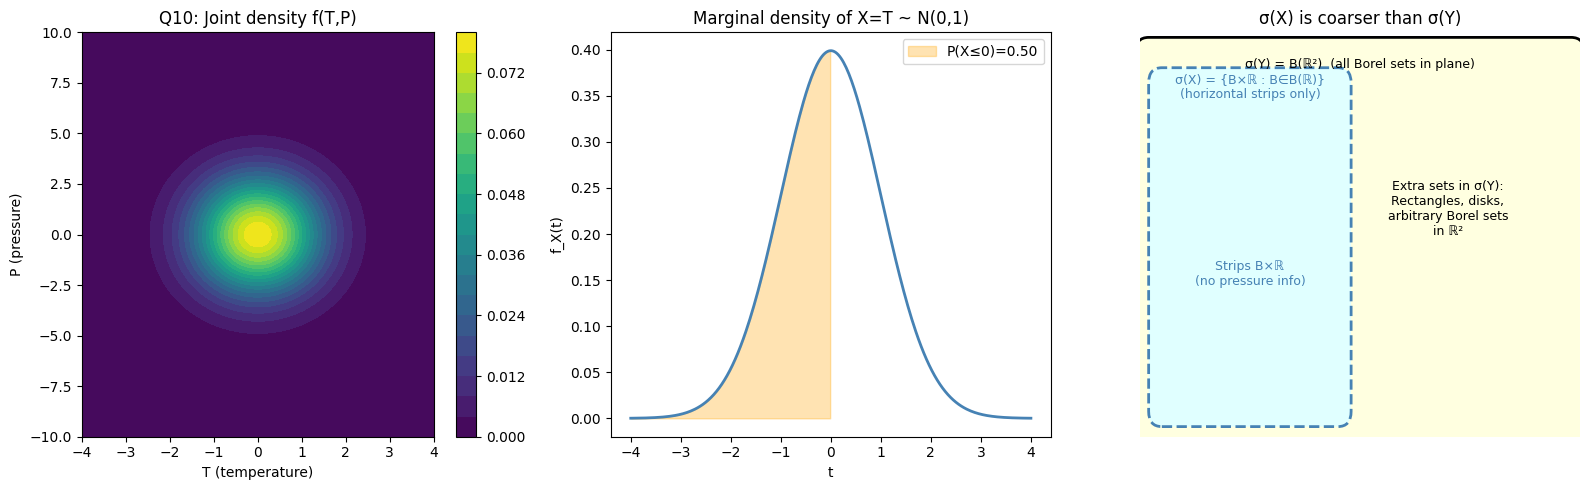


13. h(X) = (1/2)ln(2πe·1) = 1.4189 nats

14. h(Y) = h(T) + h(P) = 1.4189 + 2.1121 = 3.5310 nats

15. h(Y|X) = h(P|T) = h(P) = 2.1121 nats
    Interpretation: After observing T, we still have full uncertainty
    about P (by independence).  The remaining entropy is entirely from P.

16. h(X|Y):
    Since X = π₁(Y), knowing Y=(t,p) completely determines X=t.
    So X|Y is degenerate, but in the continuous case a degenerate
    distribution has no density → h(X|Y) = -∞ in the differential sense.

    This differs from the discrete case: in discrete probability,
    if X is a function of Y then H(X|Y)=0.  In the continuous case,
    conditioning on a continuous Y collapses the conditional
    distribution to a point mass, and the differential entropy of a
    point mass is -∞ (not 0).  This reflects the fundamental difference
    between Shannon entropy (discrete) and differential entropy (continuous).



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import dblquad, quad

# Q10: Continuous Random Variables – Temperature (T) and Pressure (P) deviations
# T ~ N(0,1),  P ~ N(0,4),  independent

# 1. Probability space
print("1. Probability Space:")
print("   Ω = ℝ²")
print("   F = B(ℝ²)  (Borel σ-algebra on ℝ²)")
print("   P induced by  f_{T,P}(t,p) = (1/4π) exp(-t²/2 - p²/8)")

# 2. σ(X)
print("""
2. σ(X) where X(t,p)=t:""")
print("   σ(X) = {X⁻¹(B) : B ∈ B(ℝ)} = {B × ℝ : B ∈ B(ℝ)}")
print("   (horizontal strips — only temperature information)")

# 3. σ(Y)
print("""
3. σ(Y) where Y(t,p)=(t,p):""")
print("   σ(Y) = B(ℝ²)  (all Borel sets in the plane)")

# 4. σ(X) ⊆ σ(Y)
print("""
4. σ(X) ⊆ σ(Y):""")
print("   Every set B×ℝ is a Borel set in ℝ², hence in σ(Y)=B(ℝ²). ✓")
print("   Y records (T,P) jointly, so it carries pressure info that X discards.")

# 5. Marginal density of X = T ~ N(0,1)
print("""
5. Marginal density of X = T:""")
print("   f_X(t) = (1/√(2π)) exp(-t²/2)   [standard normal]")

# 6. Marginal density of Y = (T,P)
print("""
6. Marginal density of Y = (T,P):""")
print("   f_Y(t,p) = (1/4π) exp(-t²/2 - p²/8)")
print("   (product of N(0,1) and N(0,4) by independence)")

# 7. Probabilities
P_X_le0 = norm.cdf(0, 0, 1)
P_X_gt1 = 1 - norm.cdf(1, 0, 1)
# P(Y ∈ (-∞,0] × ℝ) = P(T≤0) by independence and marginalising P
P_Y_strip = norm.cdf(0, 0, 1)
# P(Y ∈ [-1,1]×[-2,2]) = P(-1≤T≤1)·P(-2≤P≤2)
P_T_band = norm.cdf(1,0,1) - norm.cdf(-1,0,1)
P_P_band = norm.cdf(2,0,2) - norm.cdf(-2,0,2)   # P~N(0,4) => std=2
P_Y_rect = P_T_band * P_P_band

print(f"""
7. Probabilities:""")
print(f"   P(X ≤ 0)               = {P_X_le0:.4f}")
print(f"   P(X > 1)               = {P_X_gt1:.4f}")
print(f"   P(Y ∈ (-∞,0]×ℝ)       = P(T≤0) = {P_Y_strip:.4f}")
print(f"   P(Y ∈ [-1,1]×[-2,2])  = P(-1≤T≤1)·P(-2≤P≤2) = {P_T_band:.4f}·{P_P_band:.4f} = {P_Y_rect:.4f}")

# 8. Conditional X | Y=(t,p)
print("""
8. Conditional distribution of X given Y=(t,p):""")
print("   Since X(t,p)=t, knowing Y=(t,p) completely determines X=t.")
print("   So X|Y=(t,p) is the degenerate distribution concentrated at t.")

# 9. Conditional Y | X=t
print("""
9. Conditional distribution of Y given X=t:""")
print("   f_{Y|X=t}(t,p) = f_{T,P}(t,p)/f_T(t) = f_P(p) = (1/4√π)exp(-p²/8)")
print("   i.e. P|T=t is still N(0,4) — independence means T tells nothing about P.")

# 10.
print("""
10. Conditioning on X vs Y:
    Conditioning on X=t reveals only the temperature deviation.
    Conditioning on Y=(t,p) reveals both temperature AND pressure,
    fully pinning the state of the system.
    The extra information in Y (over X) is exactly the pressure P.
""")

# 11. X = π₁ ∘ Y
print("""11. X = π₁ ∘ Y:
    π₁(t,p) = t (projection), so X(ω) = π₁(Y(ω)) for all ω.
    Since π₁ is Borel-measurable, X is a measurable function of Y.
    This implies σ(X) ⊆ σ(Y).
""")

# 12. Visualisation
t_grid = np.linspace(-4, 4, 300)
p_grid = np.linspace(-10, 10, 300)
T_g, P_g = np.meshgrid(t_grid, p_grid)
Z = (1/(4*np.pi)) * np.exp(-T_g**2/2 - P_g**2/8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Joint density contour
cp = axes[0].contourf(T_g, P_g, Z, levels=20, cmap='viridis')
fig.colorbar(cp, ax=axes[0])
axes[0].set_xlabel('T (temperature)'); axes[0].set_ylabel('P (pressure)')
axes[0].set_title('Q10: Joint density f(T,P)')

# Marginal of X=T
axes[1].plot(t_grid, norm.pdf(t_grid, 0, 1), 'steelblue', lw=2)
axes[1].set_xlabel('t'); axes[1].set_ylabel('f_X(t)')
axes[1].set_title('Marginal density of X=T ~ N(0,1)')
axes[1].fill_between(t_grid[t_grid<=0], norm.pdf(t_grid[t_grid<=0], 0, 1),
                     alpha=0.3, color='orange', label=f'P(X≤0)={P_X_le0:.2f}')
axes[1].legend()

# σ-algebra coarseness diagram
ax3 = axes[2]
ax3.set_xlim(0,10); ax3.set_ylim(0,8); ax3.axis('off')
ax3.set_title('σ(X) is coarser than σ(Y)')
import matplotlib.patches as mpatches
ax3.add_patch(mpatches.FancyBboxPatch((0.2,0.2),9.6,7.4, boxstyle='round',
              edgecolor='black', facecolor='lightyellow', lw=2))
ax3.add_patch(mpatches.FancyBboxPatch((0.5,0.5),4,6.5, boxstyle='round',
              edgecolor='steelblue', facecolor='lightcyan', lw=2, linestyle='--'))
ax3.text(5,7.3,'σ(Y) = B(ℝ²)  (all Borel sets in plane)', ha='center', fontsize=9)
ax3.text(2.5,6.7,'''σ(X) = {B×ℝ : B∈B(ℝ)}
(horizontal strips only)''',
         ha='center', color='steelblue', fontsize=9)
ax3.text(7,4,'''Extra sets in σ(Y):
Rectangles, disks,
arbitrary Borel sets
in ℝ²''', ha='center', fontsize=9)
ax3.text(2.5,3,'''Strips B×ℝ
(no pressure info)''', ha='center', color='steelblue', fontsize=9)

plt.tight_layout()
plt.savefig('q10_viz.png', dpi=100, bbox_inches='tight')
plt.show()

# 13. Differential entropy of X ~ N(0,1)
# h(N(0,σ²)) = (1/2)ln(2πeσ²)
h_X = 0.5 * np.log(2*np.pi*np.e*1)
print(f"""
13. h(X) = (1/2)ln(2πe·1) = {h_X:.4f} nats""")

# 14. Differential entropy of Y = (T,P) with T~N(0,1), P~N(0,4), independent
# h(Y) = h(T) + h(P) by independence
h_T = 0.5 * np.log(2*np.pi*np.e*1)
h_P = 0.5 * np.log(2*np.pi*np.e*4)
h_Y = h_T + h_P
print(f"""
14. h(Y) = h(T) + h(P) = {h_T:.4f} + {h_P:.4f} = {h_Y:.4f} nats""")

# 15. h(Y|X) = h(Y) - h(X) [since X=T, and T,P independent]
# Knowing X=T, P remains N(0,4) → h(Y|X) = h(P) = h(P)
h_Y_given_X = h_P
print(f"""
15. h(Y|X) = h(P|T) = h(P) = {h_Y_given_X:.4f} nats""")
print("    Interpretation: After observing T, we still have full uncertainty")
print("    about P (by independence).  The remaining entropy is entirely from P.")

# 16. h(X|Y)
print("""
16. h(X|Y):
    Since X = π₁(Y), knowing Y=(t,p) completely determines X=t.
    So X|Y is degenerate, but in the continuous case a degenerate
    distribution has no density → h(X|Y) = -∞ in the differential sense.

    This differs from the discrete case: in discrete probability,
    if X is a function of Y then H(X|Y)=0.  In the continuous case,
    conditioning on a continuous Y collapses the conditional
    distribution to a point mass, and the differential entropy of a
    point mass is -∞ (not 0).  This reflects the fundamental difference
    between Shannon entropy (discrete) and differential entropy (continuous).
""")
